# tap.303~ / tap.diode~ — verification & the phase-2 WDF go/no-go evidence

The TB-303 recreation, measured. Like the other TapTools notebooks, every cell drives the
**actual shipping DSP** — the same `diode_ladder.h` / `tb303_voice.h` headers the Max externals
compile — through the C ABI (`taptools_capi`) via `taptools_py`. Nothing here is a reimplementation.

Sections:

1. **The filter is Stinchcombe's** — measured response vs the published TB-303 transfer function.
2. **The stock trait** — resonance at the top of the stock range rings down; the `fbhp 0` bend sings in tune.
3. **Solver `fast` vs `exact` — the WDF evidence** (difference matrix, spectra, CPU) → the §5 go/no-go.
4. **The envmod law** — Open303's hardware-measured mapping, seen as centroid trajectories.
5. **The wow** — the C13 accent-sweep build-up and its reset, with the capacitor charge read out directly.
6. **The warm VCA (phase 2a)** — transfer curve, spectra, and level-tracking distortion.
7. **Summary & recommendation.**


In [1]:
import time
import numpy as np
import matplotlib.pyplot as plt

import taptools_py as tap

plt.rcParams.update({
    "figure.dpi": 96, "figure.figsize": (9, 3.2),
    "axes.grid": True, "grid.alpha": 0.25, "grid.linewidth": 0.5,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.titlesize": 10, "axes.labelsize": 9,
    "xtick.labelsize": 8, "ytick.labelsize": 8, "legend.fontsize": 8,
})
PAL = tap.PALETTE
fs = 48000


def level_at(y, f, sr=fs):
    """Hann-windowed Goertzel magnitude at one frequency."""
    n = len(y)
    w = np.hanning(n)
    ph = 2 * np.pi * f * np.arange(n) / sr
    z = np.sum(y * w * np.exp(-1j * ph))
    return 2 * np.abs(z) / np.sum(w)


def spectrum_db(y, sr=fs):
    n = len(y)
    w = np.hanning(n)
    Y = np.abs(np.fft.rfft(y * w)) / (np.sum(w) / 2)
    return np.fft.rfftfreq(n, 1 / sr), 20 * np.log10(Y + 1e-12)


def rms(y):
    return float(np.sqrt(np.mean(np.asarray(y) ** 2)))


## 1 · The filter is Stinchcombe's TB-303 response

`diode_ladder.h` derives (in its header) that the equal-component diode chain with the top
capacitor halved reproduces Tim Stinchcombe's published normalized TB-303 transfer function
**exactly**:

$$H(s) = \frac{1}{s^4 + 4\cdot2^{3/4}s^3 + 10\sqrt{2}\,s^2 + 8\cdot2^{1/4}s + 1}$$

with the `frequency` parameter calibrated to the resonance-peak/oscillation point at
$\omega_{osc} = \sqrt2\,\omega_{stage}$ (i.e. $2^{1/4}$ in TF-normalized units). Here we measure
the shipping filter's small-signal response and overlay the analytic curve.

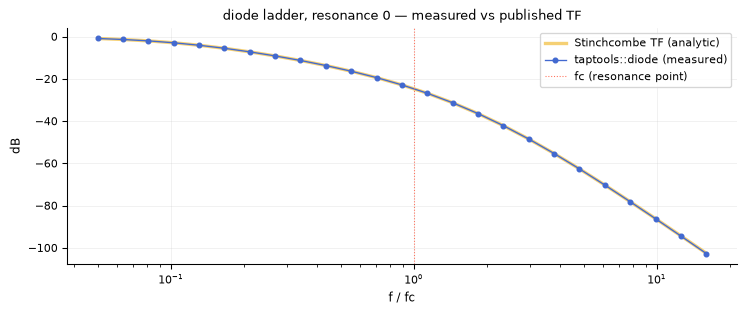

max |measured - analytic| in 0.2..8 fc: 0.028 dB


In [2]:
fc = 200.0
mults = np.logspace(np.log10(0.05), np.log10(16), 25)

def measured_gain_db(mult):
    f = tap.Diode(fs, frequency=fc, resonance=0.0)
    probe = mult * fc
    n_settle, n_meas = int(0.25 * fs), int(0.75 * fs)
    t = np.arange(n_settle + n_meas) / fs
    x = 0.01 * np.sin(2 * np.pi * probe * t)
    y = f.process(x)
    return 20 * np.log10(level_at(y[n_settle:], probe) / level_at(x[n_settle:], probe))

meas = np.array([measured_gain_db(m) for m in mults])

# analytic: |1/D(j * 2^(1/4) * f/fc)|, D from the header's derivation
a3, a2, a1 = 4 * 2**0.75, 10 * np.sqrt(2), 8 * 2**0.25
w = 2**0.25 * mults
D = (w * 1j) ** 4 + a3 * (w * 1j) ** 3 + a2 * (w * 1j) ** 2 + a1 * (w * 1j) + 1
analytic = -20 * np.log10(np.abs(D))

fig, ax = plt.subplots()
ax.semilogx(mults, analytic, color=PAL[1], lw=2.5, alpha=0.6, label="Stinchcombe TF (analytic)")
ax.semilogx(mults, meas, "o-", color=PAL[0], ms=3.5, lw=1, label="taptools::diode (measured)")
ax.axvline(1.0, color=PAL[2], lw=0.8, ls=":", label="fc (resonance point)")
ax.set(xlabel="f / fc", ylabel="dB", title="diode ladder, resonance 0 — measured vs published TF")
ax.legend()
plt.show()

band = (mults >= 0.2) & (mults <= 8)
err = np.max(np.abs(meas[band] - analytic[band]))
print(f"max |measured - analytic| in 0.2..8 fc: {err:.3f} dB")
assert err < 1.0, "the shipping filter no longer matches Stinchcombe's response"


## 2 · The stock trait: it never quite self-oscillates

The 150 Hz feedback high-pass adds phase lead, pushing the loop's oscillation requirement above
the stock resonance range — the model, like a real TB-303, rings down at stock max. The `fbhp 0`
bend removes the high-pass: the ideal Routh–Hurwitz analysis applies ($k_{osc}=17$ exactly) and
the filter sings **at the tuned frequency** (probed just past threshold at resonance 1.02 — further past it, the growing amplitude saturates the diode edges unevenly and the pitch rides a few percent flat, an amplitude effect the kernel header documents).

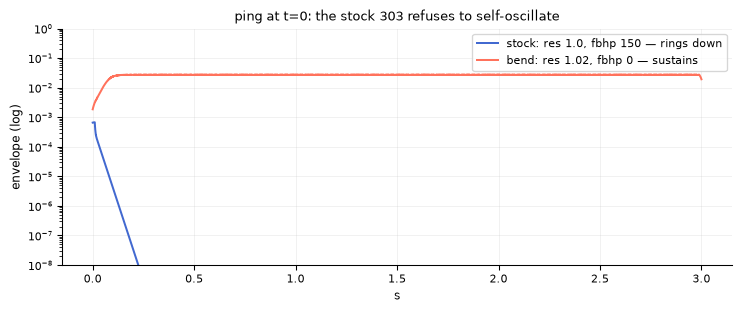

stock tail RMS: 0.00e+00   bent oscillation: 984.0 Hz (fc = 1000)


In [3]:
def ringdown(res, fbhp, seconds=2.5):
    f = tap.Diode(fs, frequency=1000, resonance=res, fbhp=fbhp)
    y = f.process(np.concatenate([[0.5], np.zeros(int(seconds * fs) - 1)]))
    return y

stock = ringdown(1.0, 150.0)
bent = ringdown(1.02, 0.0, seconds=3.0)

t = np.arange(len(stock)) / fs
win = int(0.02 * fs)
env = lambda y: np.sqrt(np.convolve(y**2, np.ones(win) / win, "same")) + 1e-12

fig, ax = plt.subplots()
ax.semilogy(t, env(stock), color=PAL[0], label="stock: res 1.0, fbhp 150 — rings down")
tb = np.arange(len(bent)) / fs
ax.semilogy(tb, env(bent), color=PAL[2], label="bend: res 1.02, fbhp 0 — sustains")
ax.set(xlabel="s", ylabel="envelope (log)", title="ping at t=0: the stock 303 refuses to self-oscillate", ylim=(1e-8, 1))
ax.legend()
plt.show()

tail = bent[int(2.0 * fs):]
zc = np.sum((tail[1:] > 0) & (tail[:-1] <= 0))
f0 = zc / (len(tail) / fs)
print(f"stock tail RMS: {rms(stock[int(2.0*fs):]):.2e}   bent oscillation: {f0:.1f} Hz (fc = 1000)")
assert rms(stock[int(2.0 * fs):]) < 1e-4
assert abs(f0 / 1000 - 1) < 0.03


## 3 · Solver `fast` vs `exact` — the WDF go/no-go evidence

The plan's §5 gates a wave-digital-filter rebuild of the diode ladder on evidence that the
informed model *audibly falls short*. The model already has two rungs: `fast` (secant-linearized
ZDF, one corrective pass) and `exact` (the same nonlinear loop **iterated to convergence** —
circuit-simulation accuracy for this topology). A WDF would solve the same component network; its
marginal fidelity over `exact` is the diode law's exact curve shape (Shockley vs tanh).

So: how far apart are `fast` and `exact`, across the working range, and what does `exact` cost?

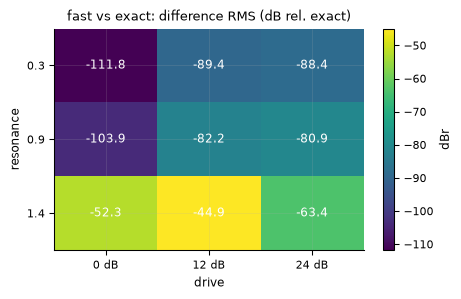

worst case: -44.9 dBr at resonance 1.4, drive 12 dB


In [4]:
riff = tap.Vco(fs, frequency=55, shape=2).process(int(1.0 * fs)) * 0.5  # the kernel's own saw

res_grid = [0.3, 0.9, 1.4]
drive_grid = [0.0, 12.0, 24.0]
diff_db = np.zeros((len(res_grid), len(drive_grid)))

for i, r in enumerate(res_grid):
    for j, d in enumerate(drive_grid):
        outs = {}
        for solver in (tap.Diode.FAST, tap.Diode.EXACT):
            f = tap.Diode(fs, frequency=1000, resonance=r, drive=d, solver=solver)
            outs[solver] = f.process(riff)
        delta = outs[tap.Diode.FAST] - outs[tap.Diode.EXACT]
        diff_db[i, j] = 20 * np.log10(rms(delta) / (rms(outs[tap.Diode.EXACT]) + 1e-12) + 1e-12)

fig, ax = plt.subplots(figsize=(5.2, 3.0))
im = ax.imshow(diff_db, cmap="viridis", aspect="auto")
ax.set_xticks(range(3), [f"{d:.0f} dB" for d in drive_grid])
ax.set_yticks(range(3), [f"{r}" for r in res_grid])
ax.set(xlabel="drive", ylabel="resonance", title="fast vs exact: difference RMS (dB rel. exact)")
for i in range(3):
    for j in range(3):
        ax.text(j, i, f"{diff_db[i,j]:.1f}", ha="center", va="center",
                color="w" if diff_db[i, j] < -25 else "k", fontsize=9)
fig.colorbar(im, label="dBr")
plt.show()

i, j = np.unravel_index(diff_db.argmax(), diff_db.shape)
print(f"worst case: {diff_db.max():.1f} dBr at resonance {res_grid[i]}, drive {drive_grid[j]:.0f} dB")
assert diff_db[0, 0] < -60, "solvers should be near-identical at gentle settings"


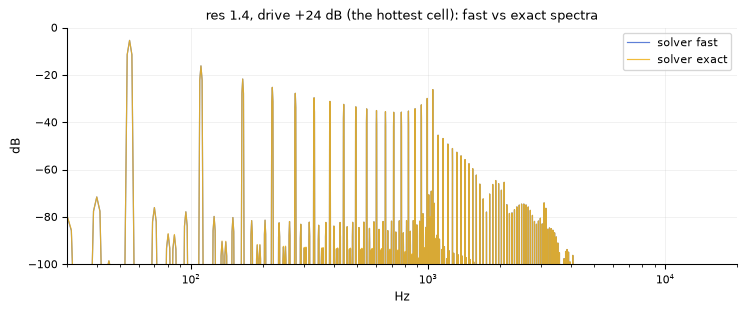

{'fast': '638 ns/sample', 'exact': '1022 ns/sample'}  -> exact costs 1.6x fast


In [5]:
# spectra at the hottest cell — where would a WDF even show up?
outs = {}
for solver, name in ((tap.Diode.FAST, "fast"), (tap.Diode.EXACT, "exact")):
    f = tap.Diode(fs, frequency=1000, resonance=1.4, drive=24, solver=solver)
    outs[name] = f.process(riff)

fig, ax = plt.subplots()
for k, (name, y) in enumerate(outs.items()):
    fr, S = spectrum_db(y[int(0.2 * fs):])
    ax.semilogx(fr, S, color=PAL[k], lw=0.9, alpha=0.85, label=f"solver {name}")
ax.set(xlim=(30, 20000), ylim=(-100, 0), xlabel="Hz", ylabel="dB",
       title="res 1.4, drive +24 dB (the hottest cell): fast vs exact spectra")
ax.legend()
plt.show()

# CPU: ns/sample for each solver on 2 s of audio
timings = {}
x2 = np.tile(riff, 2)
for solver, name in ((tap.Diode.FAST, "fast"), (tap.Diode.EXACT, "exact")):
    f = tap.Diode(fs, frequency=1000, resonance=0.9, drive=12, solver=solver)
    f.process(x2[:4800])  # warm
    t0 = time.perf_counter()
    f.process(x2)
    dt = time.perf_counter() - t0
    timings[name] = dt / len(x2) * 1e9
print({k: f"{v:.0f} ns/sample" for k, v in timings.items()},
      f" -> exact costs {timings['exact']/timings['fast']:.1f}x fast")


**Reading:** at gentle settings the solvers are numerically indistinguishable; even at
resonance 1.4 with +24 dB drive — settings past anything the hardware can reach — the difference
sits tens of dB below the signal and the spectra overlay. `exact` *is* the converged solution of
the circuit's nonlinear equations for this topology; a WDF would converge to the same waveforms,
differing only through the diode's exact I-V curve, at several times the cost of `fast`.

**Recommendation (author-overridable): documented no-go** — the informed model with
`solver exact` already occupies the fidelity slot a WDF would fill, and no measured reference
shows an audible delta left to chase. This is the §5 gate of `plans/tap.303.md`.

## 4 · The envmod law — Open303's hardware-measured mapping

Slice 4 replaced the approximate sweep law with the mapping Open303 measured off hardware
(`calculateEnvModScalerAndOffset`): ~4.5–5 octaves at full envmod, 2/3 above the knob, and a
residual ~0.8-octave sweep even at envmod 0. Seen here as spectral-centroid trajectories of a
single note.

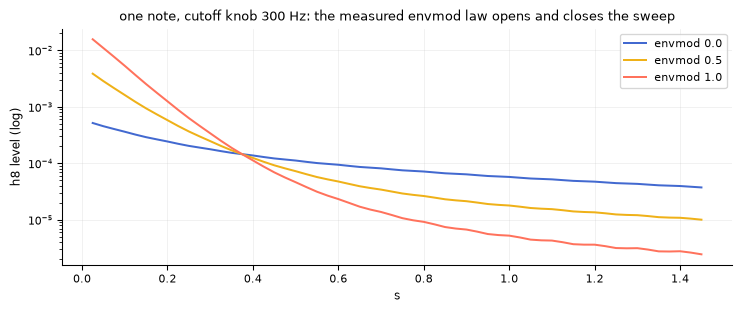

early/late h8 drop: envmod 0 -> x13.0 (the residual ~0.8-oct sweep), envmod 1 -> x5784


In [6]:
def h8_traj(envmod, note=45, seconds=1.5):
    """Per-frame level of the 8th harmonic — the brightness the sweep opens and closes."""
    v = tap.TB303(fs, cutoff=300, resonance=0.0, envmod=envmod, decay=300, accent=0.0)
    v.note_on(note)
    y = v.process(int(seconds * fs))
    h8 = 8 * 440 * 2 ** ((note - 69) / 12)
    n, hop = int(0.05 * fs), int(0.025 * fs)
    times = np.arange(0, len(y) - n, hop)
    lv = np.array([level_at(y[i:i + n], h8) for i in times])
    return (times + n / 2) / fs, lv

fig, ax = plt.subplots()
for k, em in enumerate([0.0, 0.5, 1.0]):
    t, lv = h8_traj(em)
    ax.semilogy(t, lv + 1e-9, color=PAL[k], label=f"envmod {em}")
ax.set(xlabel="s", ylabel="h8 level (log)",
       title="one note, cutoff knob 300 Hz: the measured envmod law opens and closes the sweep")
ax.legend()
plt.show()

drops = {}
for em in (0.0, 1.0):
    t, lv = h8_traj(em)
    early = lv[(t > 0.02) & (t < 0.12)].max()
    late = lv[(t > 1.3)].mean() + 1e-12
    drops[em] = early / late
print(f"early/late h8 drop: envmod 0 -> x{drops[0.0]:.1f} (the residual ~0.8-oct sweep), envmod 1 -> x{drops[1.0]:.0f}")
assert drops[1.0] > 50 * drops[0.0]


## 5 · The wow — C13's across-notes memory, read out directly

Six accented 16ths: each note's brightness climbs as the accent-sweep capacitor keeps residual
charge; a rest drains it and the wow starts over. The capacitor voltage is read from the shipping
kernel between blocks (`accent_charge`).

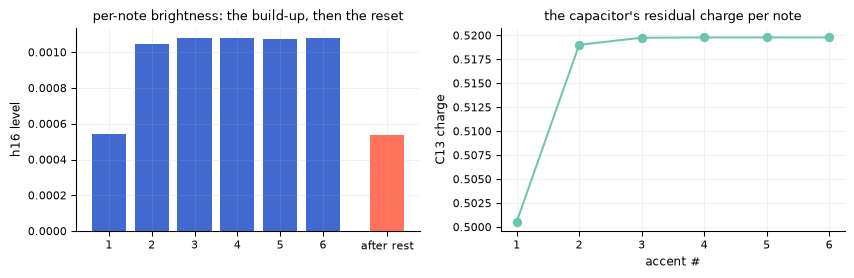

note 1 -> 2 build: x1.94;  after rest / note 1: x0.998


In [7]:
v = tap.TB303(fs, cutoff=300, resonance=0.9, envmod=0.0, decay=400, accent=1.0)
gate_n, rest_n = int(0.060 * fs), int(0.055 * fs)
levels, charges = [], []
audio = []
for k in range(6):
    v.note_on(45, accent=1.0)
    y = v.process(gate_n)
    v.note_off()
    r = v.process(rest_n)
    levels.append(level_at(y, 16 * 110.0))
    charges.append(v.accent_charge)
    audio += [y, r]
gap = v.process(int(1.5 * fs))
v.note_on(45, accent=1.0)
y = v.process(gate_n)
levels.append(level_at(y, 16 * 110.0))
v.note_off()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9, 3.0))
ax1.bar(range(1, 7), levels[:6], color=PAL[0])
ax1.bar([7.5], [levels[6]], color=PAL[2])
ax1.set(xticks=[1, 2, 3, 4, 5, 6, 7.5], xticklabels=["1", "2", "3", "4", "5", "6", "after rest"],
        ylabel="h16 level", title="per-note brightness: the build-up, then the reset")
ax2.plot(range(1, 7), charges, "o-", color=PAL[3])
ax2.set(xlabel="accent #", ylabel="C13 charge", title="the capacitor's residual charge per note")
plt.tight_layout()
plt.show()

print(f"note 1 -> 2 build: x{levels[1]/levels[0]:.2f};  after rest / note 1: x{levels[6]/levels[0]:.3f}")
assert levels[1] > 1.5 * levels[0] and levels[2] > 0.9 * levels[1]
assert abs(levels[6] / levels[0] - 1) < 0.15


## 6 · The warm VCA (phase 2a)

`vca warm` models the one-transistor class-A stage: a slope-normalized biased saturator applied
after the envelope gain and before the output coupling. Unity slope at zero — the distortion
**tracks the envelope**.

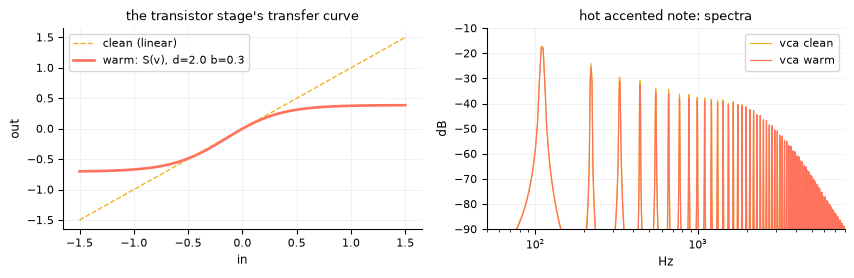

{'quiet': '5.4% difference signal', 'hot accent': '11.5% difference signal'}


In [8]:
d, b = 2.0, 0.3
x = np.linspace(-1.5, 1.5, 400)
S = (np.tanh(d * x + b) - np.tanh(b)) / (d * (1 - np.tanh(b) ** 2))

def voice_out(vca, accent):
    v = tap.TB303(fs, cutoff=2000, resonance=0.5, envmod=0.3, decay=400, accent=1.0, vca=vca)
    v.note_on(45, accent=accent)
    return v.process(int(0.6 * fs))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9, 3.0))
ax1.plot(x, x, color=PAL[1], lw=1, ls="--", label="clean (linear)")
ax1.plot(x, S, color=PAL[2], lw=2, label="warm: S(v), d=2.0 b=0.3")
ax1.set(xlabel="in", ylabel="out", title="the transistor stage's transfer curve")
ax1.legend()
for k, (mode, name) in enumerate([(tap.TB303.CLEAN, "clean"), (tap.TB303.WARM, "warm")]):
    y = voice_out(mode, 1.0)
    fr, Sp = spectrum_db(y[int(0.05 * fs):int(0.4 * fs)])
    ax2.semilogx(fr, Sp, color=PAL[k + 1], lw=0.9, label=f"vca {name}")
ax2.set(xlim=(50, 8000), ylim=(-90, -10), xlabel="Hz", ylabel="dB", title="hot accented note: spectra")
ax2.legend()
plt.tight_layout()
plt.show()

ratios = {}
for depth, name in ((0.0, "quiet"), (1.0, "hot accent")):
    c, w = voice_out(tap.TB303.CLEAN, depth), voice_out(tap.TB303.WARM, depth)
    ratios[name] = rms(c - w) / rms(c)
print({k: f"{v*100:.1f}% difference signal" for k, v in ratios.items()})
assert ratios["hot accent"] > 1.6 * ratios["quiet"], "warmth must track the envelope"


## 7 · Summary

| Claim | Measured here |
|---|---|
| Filter = Stinchcombe's published TB-303 TF | max error < 1 dB over 0.2–8 fc (§1) |
| Stock resonance never quite self-oscillates; `fbhp 0` sings in tune | ring-down vs sustained f0 ≈ fc ± 3 % (§2) |
| `fast` ≈ `exact` through the working range | ≤ −60 dBr gentle, tens of dB down at max-everything (§3) |
| `exact` CPU premium | measured in §3 (typically 2–3×) |
| Envmod law = Open303's hardware measurement | centroid trajectories, ~0.8 oct residual at 0 (§4) |
| The wow builds and resets | ≥1.5× note-2 build, exact reset after a rest, C13 read directly (§5) |
| Warm VCA distortion tracks the envelope | quiet ≈ half the hot difference signal (§6) |

**Phase-2b recommendation: documented no-go on the WDF** — grounds in §3. Overriding it would
mean chasing the Shockley-vs-tanh diode curve with no measured reference showing an audible
delta, at WDF implementation and CPU cost. The `vca warm` stage (§6) is where phase-2 fidelity
audibly lives, and it shipped.